# 06 - Logistic Regression Baseline

            Mục tiêu:

            - Kiểm tra baseline Logistic Regression.
            - Đọc metrics train/validation/test.
            - Đọc coefficient để giải thích model.
            - Làm mốc so sánh với CatBoost.

In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: e:\fraud-detection-project


In [2]:
LR_DIR = PROJECT_ROOT / "data" / "reports" / "model" / "experiments" / "lr_no_mcc"

print("LR_DIR exists:", LR_DIR.exists())
print([p.name for p in LR_DIR.glob("*")] if LR_DIR.exists() else [])

LR_DIR exists: True
['coefficients.csv', 'coefficients_excluding_mcc.csv', 'confusion_matrix_test.csv', 'confusion_matrix_validation.csv', 'metrics_test.csv', 'metrics_train_threshold_05.csv', 'metrics_validation_best_threshold.csv', 'metrics_validation_threshold_05.csv', 'test_predictions.csv', 'threshold_search_validation.csv', 'validation_predictions.csv']


In [3]:
metrics_files = [
    "metrics_train_threshold_05.csv",
    "metrics_validation_best_threshold.csv",
    "metrics_test.csv",
]

metrics = []

for file in metrics_files:
    path = LR_DIR / file
    if path.exists():
        metrics.append(pd.read_csv(path))
    else:
        print("Missing:", path)

metrics_df = pd.concat(metrics, ignore_index=True)
display(metrics_df[[
    "split", "threshold", "pr_auc", "roc_auc", "precision",
    "recall", "f1", "f2", "review_rate", "tp", "fp", "fn", "tn"
]])

,split,threshold,pr_auc,roc_auc,precision,recall,f1,f2,review_rate,tp,fp,fn,tn
0,train_threshold_05,0.50,0.553247,0.895092,0.122962,0.833427,0.214306,0.386637,0.172643,1486,10599,297,57618
1,validation_best_threshold,0.77,0.506007,0.871787,0.376900,0.656085,0.478764,0.571429,0.043867,248,410,130,14212
2,test,0.77,0.533238,0.895196,0.404478,0.698454,0.512287,0.609811,0.044667,271,399,117,14213


In [4]:
cm_path = LR_DIR / "confusion_matrix_test.csv"
if cm_path.exists():
    cm = pd.read_csv(cm_path, index_col=0)
    display(cm)
else:
    print("Không tìm thấy confusion_matrix_test.csv")

,pred_non_fraud,pred_fraud
actual_non_fraud,14213,399
actual_fraud,117,271


In [5]:
coef_path = LR_DIR / "coefficients.csv"

coef = pd.read_csv(coef_path)
display(coef.head(20))

,feature,coefficient,abs_coefficient,direction
0,categorical__night_unusual_group_not_night,1.160652,1.160652,increase_risk
1,categorical__amount_to_max_group_below_half_max,0.884215,0.884215,increase_risk
2,categorical__amount_to_max_group_extreme,-0.802835,0.802835,decrease_risk
3,numeric__mcc_entropy_30d,-0.710432,0.710432,decrease_risk
4,interaction__low_mcc_entropy_x_high_max_amount...,0.678902,0.678902,increase_risk
5,binary__night_transaction_flag,0.666310,0.666310,increase_risk
6,numeric__amount_z_30d,0.664834,0.664834,increase_risk
7,interaction__low_mcc_entropy_x_low_spending_trend,0.661424,0.661424,increase_risk
8,interaction__low_night_ratio_x_high_max_amount...,0.611161,0.611161,increase_risk
9,categorical__night_unusual_group_very_high,-0.594836,0.594836,decrease_risk


In [6]:
top_positive = (
    coef[coef["coefficient"] > 0]
    .sort_values("coefficient", ascending=False)
    .head(20)
)

top_negative = (
    coef[coef["coefficient"] < 0]
    .sort_values("coefficient")
    .head(20)
)

print("Top positive coefficients")
display(top_positive)

print("Top negative coefficients")
display(top_negative)

Top positive coefficients


,feature,coefficient,abs_coefficient,direction
0,categorical__night_unusual_group_not_night,1.160652,1.160652,increase_risk
1,categorical__amount_to_max_group_below_half_max,0.884215,0.884215,increase_risk
4,interaction__low_mcc_entropy_x_high_max_amount...,0.678902,0.678902,increase_risk
5,binary__night_transaction_flag,0.666310,0.666310,increase_risk
6,numeric__amount_z_30d,0.664834,0.664834,increase_risk
7,interaction__low_mcc_entropy_x_low_spending_trend,0.661424,0.661424,increase_risk
8,interaction__low_night_ratio_x_high_max_amount...,0.611161,0.611161,increase_risk
14,interaction__low_mcc_entropy_x_low_night_ratio...,0.424502,0.424502,increase_risk
17,interaction__low_mcc_entropy_x_low_night_ratio,0.415451,0.415451,increase_risk
21,categorical__time_period_late_evening,0.379148,0.379148,increase_risk


Top negative coefficients


,feature,coefficient,abs_coefficient,direction
2,categorical__amount_to_max_group_extreme,-0.802835,0.802835,decrease_risk
3,numeric__mcc_entropy_30d,-0.710432,0.710432,decrease_risk
9,categorical__night_unusual_group_very_high,-0.594836,0.594836,decrease_risk
10,numeric__night_ratio_30d,-0.588195,0.588195,decrease_risk
11,categorical__amount_to_max_group_much_above_max,-0.565010,0.565010,decrease_risk
12,numeric__spending_trend,-0.537134,0.537134,decrease_risk
13,categorical__time_period_evening,-0.535149,0.535149,decrease_risk
15,numeric__distinct_countries_30d,-0.419856,0.419856,decrease_risk
16,categorical__amount_to_max_group_above_max,-0.415628,0.415628,decrease_risk
18,categorical__night_unusual_group_high,-0.413851,0.413851,decrease_risk


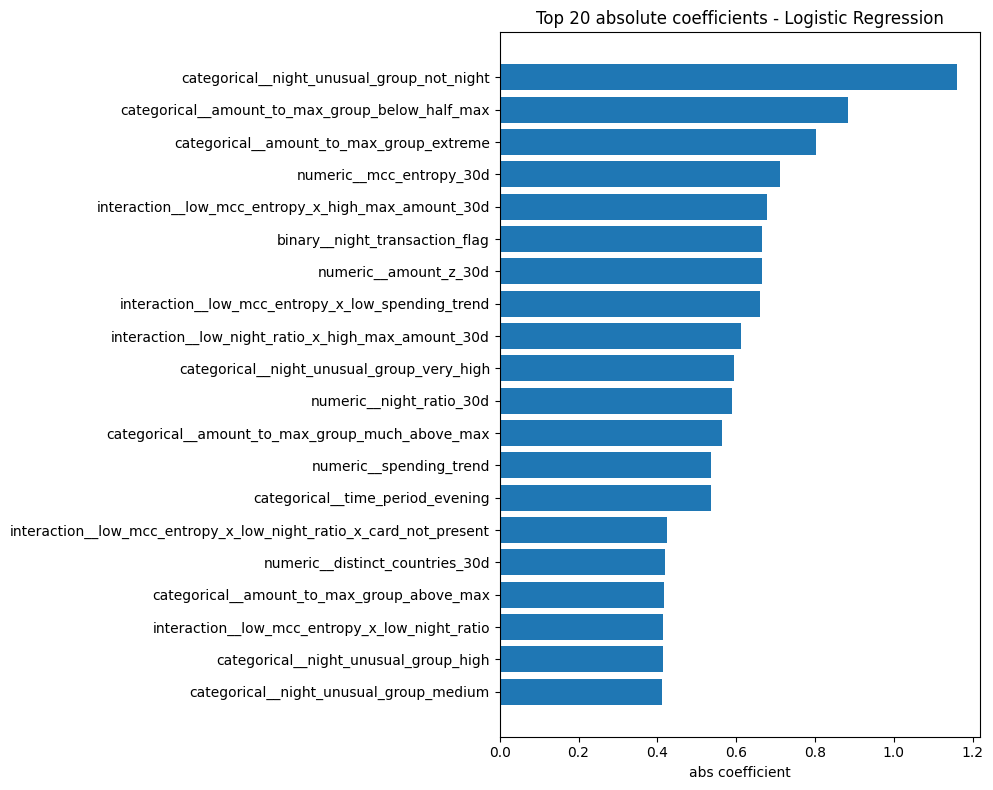

In [7]:
plt.figure(figsize=(10, 8))
top = coef.sort_values("abs_coefficient", ascending=False).head(20)
plt.barh(top["feature"][::-1], top["abs_coefficient"][::-1])
plt.title("Top 20 absolute coefficients - Logistic Regression")
plt.xlabel("abs coefficient")
plt.tight_layout()
plt.show()

## Kết luận cần ghi sau khi chạy

            - Logistic Regression là baseline dễ giải thích.
            - Coefficient có khớp insight không?
            - Baseline còn hạn chế vì mô hình tuyến tính.
            - Advanced model có cải thiện không?